In [19]:
import pandas as pd
import glob
import os

# 1. Setup paths
input_folder = os.path.join('..', 'data')
all_files = glob.glob(os.path.join(input_folder, "*_clean.csv"))

li = []
for filename in all_files:
    temp_df = pd.read_csv(filename)
    country_name = os.path.basename(filename).split('_')[0].capitalize()
    
    # Standardize all column names to lowercase for consistency
    temp_df.columns = temp_df.columns.str.lower()
    temp_df['country'] = country_name
    
    # Ensure date column is a datetime object
    if 'date' in temp_df.columns:
        temp_df['date'] = pd.to_datetime(temp_df['date'])
        
    li.append(temp_df)

# 2. Combine everything into one robust DataFrame
df = pd.concat(li, axis=0, ignore_index=True)

print("✅ Full Master DF Loaded!")
print(f"Verified Columns: {df.columns.tolist()}")

✅ Full Master DF Loaded!
Verified Columns: ['year', 'doy', 't2m', 't2m_max', 't2m_min', 't2m_range', 'prectotcorr', 'rh2m', 'ws2m', 'ws2m_max', 'ps', 'qv2m', 'country', 'date', 'month', 'country.1']


📊 Statistical KPI: ANOVA F-Statistic = 4380.33, p < 0.001


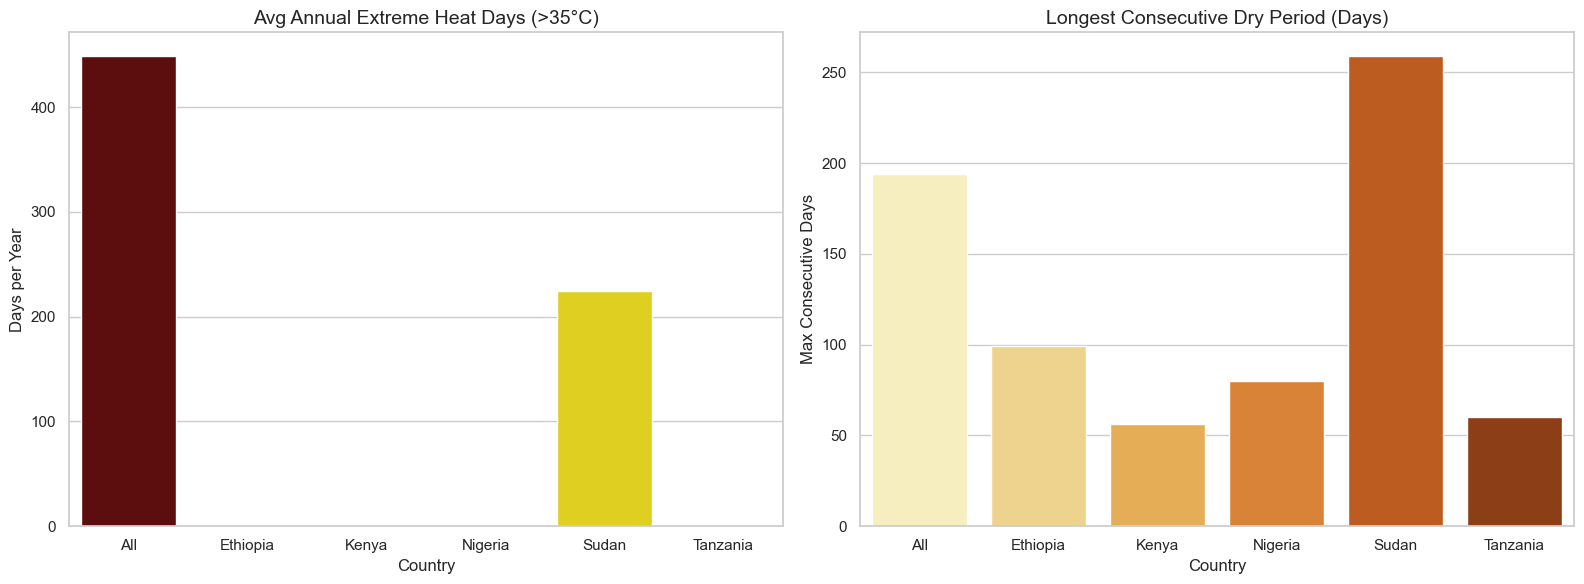

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. STATISTICAL TEST (ANOVA) ---
groups = [group['t2m'].dropna() for name, group in df.groupby('country')]
f_stat, p_val = stats.f_oneway(*groups)

# Format p-value for human readability
p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.4f}"
print(f"📊 Statistical KPI: ANOVA F-Statistic = {f_stat:.2f}, {p_text}")

# --- 2. UPDATED PLOTTING (No Warnings) ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heat Chart - Added hue=x and legend=False to satisfy the new Seaborn rules
sns.barplot(data=ext_df, x='Country', y='Heat_Days', hue='Country', palette='hot', ax=ax1, legend=False)
ax1.set_title('Avg Annual Extreme Heat Days (>35°C)', fontsize=14)
ax1.set_ylabel('Days per Year')

# Drought Chart
sns.barplot(data=ext_df, x='Country', y='Dry_Spell', hue='Country', palette='YlOrBr', ax=ax2, legend=False)
ax2.set_title('Longest Consecutive Dry Period (Days)', fontsize=14)
ax2.set_ylabel('Max Consecutive Days')

plt.tight_layout()
plt.show()

In [21]:
# Create the summary table for both Temp and Rain
summary_table = df.groupby('country').agg({
    't2m': ['mean', 'median', 'std'],
    'prectotcorr': ['mean', 'median', 'std']
})

# Flatten the multi-index columns for readability
summary_table.columns = [f"{col[0]}_{col[1]}" for col in summary_table.columns]

print("🏆 VULNERABILITY RANKING DATA")
display(summary_table.round(2))

🏆 VULNERABILITY RANKING DATA


,t2m_mean,t2m_median,t2m_std,prectotcorr_mean,prectotcorr_median,prectotcorr_std
country,,,,,,
All,23.74,25.21,5.36,2.74,0.39,6.10
Ethiopia,16.07,16.04,1.90,3.63,0.82,6.29
Kenya,20.43,20.36,1.44,1.47,0.38,3.18
Nigeria,26.66,26.82,1.12,4.21,1.84,7.27
Sudan,28.76,29.16,4.68,0.64,0.00,3.06
Tanzania,26.80,26.99,1.33,3.74,0.64,8.00


In [ ]:
from scipy.stats import f_oneway

# Grouping data for the ANOVA test
eth = df[df['country'] == 'Ethiopia']['t2m']
ken = df[df['country'] == 'Kenya']['t2m']
sud = df[df['country'] == 'Sudan']['t2m']
nig = df[df['country'] == 'Nigeria']['t2m']
tan = df[df['country'] == 'Tanzania']['t2m']

# Run ANOVA
stat, p = f_oneway(eth, ken, sud, nig, tan)

print(f"ANOVA Result: p-value = {p:.4e}")
if p < 0.05:
    print("The differences in temperature between countries are statistically significant.")

# Simple summary table for the final ranking
summary = df.groupby('country').agg({
    't2m': 'mean',
    'prectotcorr': 'std'
}).rename(columns={'t2m': 'Avg_Temp', 'prectotcorr': 'Rain_Volatility'})

print("\n--- Vulnerability Summary ---")
print(summary.sort_values(by='Avg_Temp', ascending=False))